# Machine Learning For Computer Science
## Image Classification For Fashion-MNIST Using MLP

Instructor: Pro. Nguyen An Khuong

Student: Tran Thi Van Anh

Student number: 2570394

### 1. Import libraries

In [50]:
!pip install d2l==1.0.3 --no-deps

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
from torchvision import transforms
from torchvision.datasets import FashionMNIST

from torch.utils.data import DataLoader

import seaborn as sns
from d2l import torch as d2l
from sklearn.metrics import confusion_matrix, classification_report

In [52]:
# Fixed random seed for reproducibility
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Activate fixed result
set_seed(42)

# If the GPU is available use it for the computation otherwise use the CPU.
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

### 2. Load and explore data

In [53]:
class_names = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
              'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Image shape: torch.Size([128, 1, 28, 28])
Label shape: torch.Size([128])


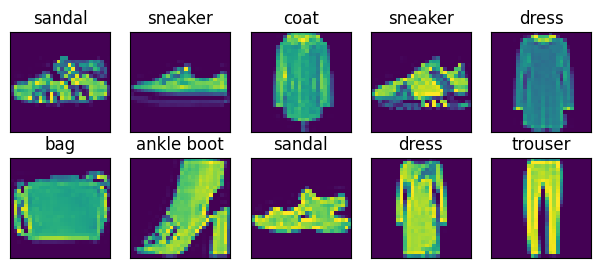

In [54]:
# Req 1: Explore data
BATCH_SIZE = 128
# Load original Fashion-MNIST dataset
train_iter, test_iter = d2l.load_data_fashion_mnist(BATCH_SIZE, resize=None)

# Check the image structure
X_raw, y_raw = next(iter(train_iter))
print(f"Image shape: {X_raw.shape}")
print(f"Label shape: {y_raw.shape}")

# Visualization the images
d2l.show_images(
    X_raw[0:10].reshape(10, 28, 28),
    num_rows=2,
    num_cols=5,
    titles=[class_names[i] for i in y_raw[0:10].numpy()]
)
plt.show()


### 3. Preprocess data

In [55]:
# Req 2: Data preprocessing data
# Define the transform
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
    ])

# Load training dataset
trainset = FashionMNIST(root='./data', train=True, download=True, transform=transform)

# Load test dataset
testset = FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Create dataloader
train_iter = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
test_iter = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False)

# Check new size after preprocessing
X_transformed, y_transformed = next(iter(train_iter))
print(f"Image size after preprocessing: {X_transformed.shape}")

Image size after preprocessing: torch.Size([128, 1, 32, 32])


### 4. Build MLP architecture

In [79]:
# Req 3: Build architecture
class FashionMLP(nn.Module):
    def __init__(self):
        super(FashionMLP, self).__init__()
        self.flatten = nn.Flatten()
        self.mlp = nn.Sequential(
            nn.Linear(32 * 32, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 10)
        )

    def forward(self, x):
       return self.mlp(self.flatten(x))

# Create model
model = FashionMLP().to(device)
print(model)

FashionMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (mlp): Sequential(
    (0): Linear(in_features=1024, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=10, bias=True)
  )
)


### 5. Loss function and optimizer

In [80]:
# Req 4
# Define the loss function
criterion = nn.CrossEntropyLoss()

# Define the optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

### 6. Train model

In [81]:
# REQ 5 & 6: Train loop and regularization

# Lists to store loss and accuracy values for plotting
train_loss = []
train_acc = []
test_loss = []
test_acc = []

# Number of epochs for training
epochs = 40

# Define Early stopping parameters
best_test_loss = float('inf')
patience = 4
counter = 0

def train():
    global best_test_loss
    global counter

    for epoch in range(epochs):

        # Switch model to training mode
        model.train()

        # Accumulate the total loss for averaging
        running_loss = 0.0
        # Count the number of correct predictions
        correct_predictions = 0
        # Count the total number of samples
        total_samples = 0

        # -------- TRAINING LOOP --------
        for images, labels in train_iter:

            # Move data to device
            images, labels = images.to(device), labels.to(device)

            # Reset gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)
            # Compute loss
            loss = criterion(outputs, labels)

            # Backward pass and update
            # Backpropagation process
            loss.backward()
            # Update weights
            optimizer.step()

            # Accumulate loss for averaging
            running_loss += loss.item()

            # Compute accuracy
            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

        # Compute average train loss after one training epoch
        avg_loss = running_loss / len(train_iter)
        # Compute training accuracy
        accuracy = 100 * correct_predictions / total_samples

        # -------- VALIDATION LOOP --------
        model.eval()

        test_running_loss = 0.0
        test_correct_predictions = 0
        test_total_samples = 0

        # Disable gradient calculation
        with torch.no_grad():
           for test_images, test_labels in test_iter:

                # Move data to device
                test_images = test_images.to(device)
                test_labels = test_labels.to(device)

                # Forward pass: Get model predictions
                test_outputs = model(test_images)
                # Compute test loss
                loss = criterion(test_outputs, test_labels)

                test_running_loss += loss.item()

                # Compute predictions
                _, test_predicted = torch.max(test_outputs.data, 1)
                test_total_samples += test_labels.size(0)
                test_correct_predictions += (test_predicted == test_labels).sum().item()

        # Compute average test loss
        test_avg_loss = test_running_loss / len(test_iter)
        # Compute test accuracy
        test_accuracy = 100 * test_correct_predictions / test_total_samples

        # Store loss and accuracy into the list
        train_loss.append(avg_loss)
        train_acc.append(accuracy)
        test_loss.append(test_avg_loss)
        test_acc.append(test_accuracy)

        # Print results
        print(
          f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Loss: {avg_loss:.4f} | "
          f"Train Acc: {accuracy:.2f}% | "
          f"Test Loss: {test_avg_loss:.4f} | "
          f"Test Acc: {test_accuracy:.2f}%"
        )

        # Req 6: Early stopping
        if test_avg_loss < best_test_loss:
          best_test_loss = test_avg_loss
          counter = 0
        else:
              counter += 1

              if counter >= patience:
                 print("Early stopping triggered.Training stopped.")
                 break

# Start training
train()

Epoch [1/40] | Train Loss: 0.5100 | Train Acc: 82.54% | Test Loss: 0.4014 | Test Acc: 85.48%
Epoch [2/40] | Train Loss: 0.3790 | Train Acc: 86.17% | Test Loss: 0.3838 | Test Acc: 85.80%
Epoch [3/40] | Train Loss: 0.3468 | Train Acc: 87.28% | Test Loss: 0.3473 | Test Acc: 87.40%
Epoch [4/40] | Train Loss: 0.3251 | Train Acc: 88.09% | Test Loss: 0.3485 | Test Acc: 87.00%
Epoch [5/40] | Train Loss: 0.3105 | Train Acc: 88.49% | Test Loss: 0.3341 | Test Acc: 87.79%
Epoch [6/40] | Train Loss: 0.2968 | Train Acc: 89.01% | Test Loss: 0.3229 | Test Acc: 88.51%
Epoch [7/40] | Train Loss: 0.2875 | Train Acc: 89.25% | Test Loss: 0.3192 | Test Acc: 88.54%
Epoch [8/40] | Train Loss: 0.2752 | Train Acc: 89.77% | Test Loss: 0.3115 | Test Acc: 88.71%
Epoch [9/40] | Train Loss: 0.2696 | Train Acc: 89.97% | Test Loss: 0.2969 | Test Acc: 89.15%
Epoch [10/40] | Train Loss: 0.2611 | Train Acc: 90.27% | Test Loss: 0.3002 | Test Acc: 89.39%
Epoch [11/40] | Train Loss: 0.2537 | Train Acc: 90.48% | Test Loss: 0

In [ ]:
# Req 7: Experiments
# Experiement 1: lr = 0.001
# Experiement 2: lr = 0.003
# Experiement 3: lr = 0.0001

### 7. Plot the loss and accuracy

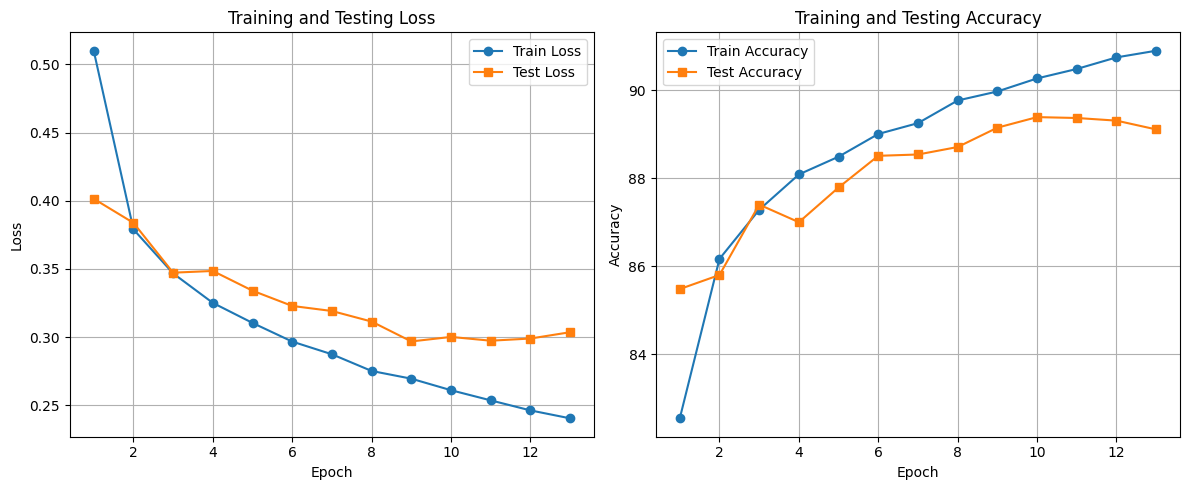

In [82]:
# Req 8: Learning Curves
# Plot training and validation loss
plt.figure(figsize=(12, 5))

# Subplot 1: Loss curve
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss) + 1), train_loss, label='Train Loss', marker='o')
plt.plot(range(1, len(test_loss) + 1), test_loss, label='Test Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Testing Loss')
plt.grid(True)
plt.legend()

# Subplot 2: Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_acc) + 1), train_acc, label='Train Accuracy', marker='o')
plt.plot(range(1, len(test_acc) + 1), test_acc, label='Test Accuracy', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Testing Accuracy')
plt.grid(True)
plt.legend()

# Display the plots
plt.tight_layout()
plt.savefig('curves_dropout02__batchnorm_lr0001.png', dpi=300)
plt.show()



Classification Report:

              precision    recall  f1-score   support

     t-shirt       0.83      0.88      0.85      1000
     trouser       0.98      0.98      0.98      1000
    pullover       0.81      0.82      0.82      1000
       dress       0.91      0.89      0.90      1000
        coat       0.83      0.78      0.81      1000
      sandal       0.98      0.94      0.96      1000
       shirt       0.71      0.71      0.71      1000
     sneaker       0.94      0.96      0.95      1000
         bag       0.97      0.98      0.97      1000
  ankle boot       0.95      0.96      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



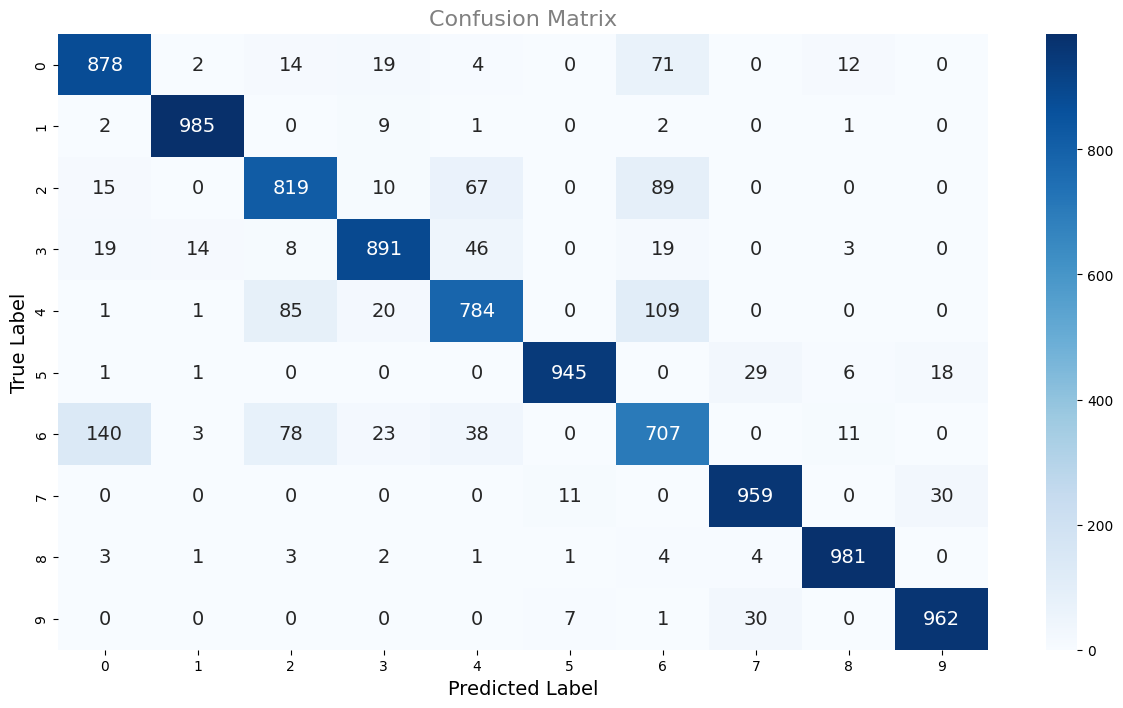

In [84]:
# Req 9: Evaluation
all_preds = []

all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_iter:

        images, labels = images.to(device), labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Classification Report
print("\nClassification Report:\n")

print(classification_report(all_labels, all_preds, target_names=class_names)
)

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

# Set figure size
plt.figure(figsize=(15, 8))

sns.heatmap(cm, annot=True, fmt='d', annot_kws={"size":14}, cmap='Blues')

# Label the axes
plt.xlabel("Predicted Label", fontsize=14)

plt.ylabel("True Label", fontsize=14)

plt.title("Confusion Matrix", color="gray", fontsize=16)

# Display the plot
plt.show()


In [ ]:
# Req 10
print("\nREQ 10 - Advanced Technique Proposal")

print(
    "One possible improvement is Batch Normalization. "
    "BatchNorm can stabilize training, accelerate "
    "convergence, and improve generalization."
)


REQ 10 - Advanced Technique Proposal
One possible improvement is Batch Normalization. BatchNorm can stabilize training, accelerate convergence, and improve generalization.
